In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs_trading.data.loaders import load_prices
from pairs_trading.config import SplitConfig
from pairs_trading.models.ols_hedge import OLSHedge
from pairs_trading.signals.zscore import rolling_zscore, generate_signal
from pairs_trading.backtest.engine import BacktestEngine

First let's build a dataframe containing all the tickers that we want to test. Split between train and test sets.

In [24]:
tickers = ["IAU", "GDX", "GLD", "SLV", "OIH", "XLE", "REM", "VNQ"]
df_train = load_prices(tickers, SplitConfig.train_start, SplitConfig.train_end, refresh=True)
df_test = load_prices(tickers, SplitConfig.test_start, SplitConfig.test_end, refresh=True)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


Run the training-testing pipeline on all 4 pairs and return the resulting metrics

In [25]:
pairs = [["IAU", "GDX"],["GLD", "SLV"], ["OIH", "XLE"], ["REM", "VNQ"]]

Final test results for trading GDX against IAU:
sharpe: -1.6066775256526504
max_drawdown: 0.207999484317041
hit_rate: 0.4090909090909091
average_holding_period: 30.285714285714285
n_trades: 7
----------------------------------------


Final test results for trading SLV against GLD:
sharpe: 0.2931673028232128
max_drawdown: 0.461242746685376
hit_rate: 0.47985347985347987
average_holding_period: 33.125
n_trades: 7
----------------------------------------


Final test results for trading XLE against OIH:
sharpe: 0.5100526795013424
max_drawdown: 0.5982543108708899
hit_rate: 0.48743718592964824
average_holding_period: 15.5
n_trades: 12
----------------------------------------


Final test results for trading VNQ against REM:
sharpe: 0.37782355381011945
max_drawdown: 0.11946702657494959
hit_rate: 0.4975609756097561
average_holding_period: 16.545454545454547
n_trades: 12
----------------------------------------




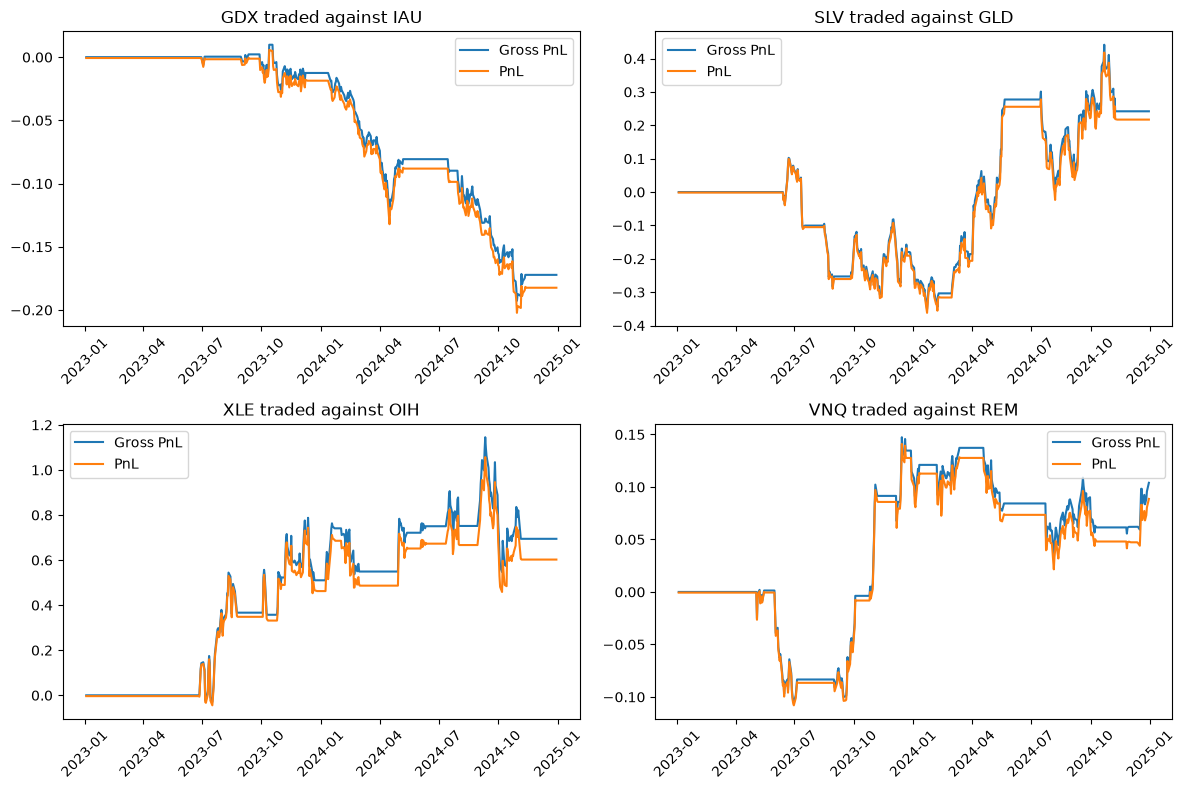

In [31]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):
    hedge = OLSHedge()
    hedge.fit(df_train[y], df_train[x])
    residuals = hedge.spread(df_test[y], df_test[x])
    zscores = rolling_zscore(residuals)
    signals = generate_signal(zscores)
    hedge_ratios = pd.Series(hedge.beta, index=signals.index)
    engine = BacktestEngine()
    result = engine.run(df_test[y], df_test[x], signals, hedge_ratios)
    print(f"Final test results for trading {x} against {y}:")
    for key, value in result.metrics.items():
        print(f"{key}: {value}")
    print("-"*40)
    print("\n")
    axs[i].plot(result.gross_pnl.cumsum(), label="Gross PnL")
    axs[i].plot(result.pnl.cumsum(), label="PnL")
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
